# I. Introduction

This notebook is purposed to deliver data-driven analysis for McDonald's reviews

created by : Ghozie Ikhsan Fairuz

# II. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

from matplotlib.patches import Patch



# III. Data Loading

In [2]:
# Read file csv
df= pd.read_csv('McDonald_s_Reviews.csv', encoding='latin1')
print(df.shape)

# Summary Information of dfset
df.info()
print('\n')

# Summary statistic deskriptive numerical columns
print('Describe Numeric:')
display(df.describe(include=[np.number]).T)
print('\n')

# Duplicated df
print(f'Number of Duplicated df: {df.duplicated().sum()}\n')

# Missing Values df
print(f'Number of Missing Values df: {df.isnull().sum()}\n')

# Displays the first 10 df and the last 10 df
print("The first 10 df:")
display(df.head(10))

print("The Last 10 df:")
display(df.tail(10))

(33396, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  object 
 2   category       33396 non-null  object 
 3   store_address  33396 non-null  object 
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  object 
 7   review_time    33396 non-null  object 
 8   review         33396 non-null  object 
 9   rating         33396 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.5+ MB


Describe Numeric:


,count,mean,std,min,25%,50%,75%,max
reviewer_id,33396.0,16698.500000,9640.739131,1.000000,8349.750000,16698.500000,25047.250000,33396.00000
latitude,32736.0,34.442546,5.344116,25.790295,28.655350,33.931261,40.727401,44.98141
longitude,32736.0,-90.647033,16.594844,-121.995421,-97.792874,-81.471414,-75.399919,-73.45982




Number of Duplicated df: 0

Number of Missing Values df: reviewer_id        0
store_name         0
category           0
store_address      0
latitude         660
longitude        660
rating_count       0
review_time        0
review             0
rating             0
dtype: int64

The first 10 df:


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star
5,6,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 weeks ago,I work for door dash and they locked us all ou...,1 star
6,7,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,If I could give this location a zero on custo...,1 star
7,8,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a year ago,Came in and ordered a Large coffee w/no ice. T...,1 star
8,9,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Went thru drive thru. Ordered. Getting home no...,1 star
9,10,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,"I'm not really a huge fan of fast food, but I ...",4 stars


The Last 10 df:


,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
33386,33387,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",a year ago,Great in fast food ï¿½ï¿½ï¿,5 stars
33387,33388,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",6 years ago,"Excellent location and very good atmosphere, e...",5 stars
33388,33389,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",3 years ago,All very good food attention,5 stars
33389,33390,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",5 years ago,Quiet open the local January 1.,4 stars
33390,33391,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",a year ago,Very. Well,5 stars
33391,33392,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",4 years ago,They treated me very badly.,1 star
33392,33393,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",a year ago,The service is very good,5 stars
33393,33394,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",a year ago,To remove hunger is enough,4 stars
33394,33395,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",5 years ago,"It's good, but lately it has become very expen...",5 stars
33395,33396,McDonald's,Fast food restaurant,"3501 Biscayne Blvd, Miami, FL 33137, United St...",25.81,-80.189098,"2,810",2 years ago,they took good care of me,5 stars


## Text Cleaning

In [ ]:
def clean_text(text):
    '''Function for cleaning text (lowercasing, removing symbol, and whitespace)'''
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s\.]", "", text)  # keep huruf & titik
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["review"].apply(clean_text)

# IV. EDA

## Rating Distribution

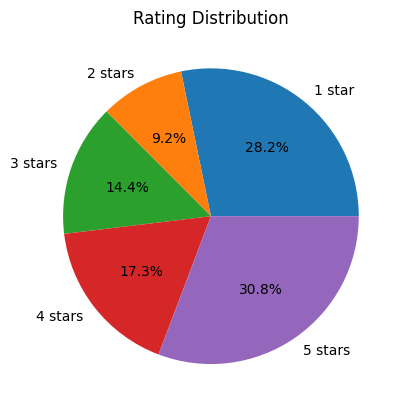

In [ ]:
# Rating count
rating_counts = df["rating"].value_counts().sort_index()

# Percentage count
rating_percent = rating_counts / rating_counts.sum() * 100

# Plot pie chart
plt.figure()
plt.pie(
    rating_percent,
    labels=rating_percent.index,
    autopct="%1.1f%%"
)

plt.title("Rating Distribution")
plt.show()

Based on the pie chart above, we can see that customer ratings tend to skew toward very good or extremely negative, while remaining balanced at ratings 2-4. However, the fact that the highest rating is so close to the lowest rating may reflect personal prejudice. Furthermore, the ratings 2-4 are rather evenly distributed. On the other side, the data demonstrates that the customer ratings is valid.

## Top 3 words Review every rating

### Keyword definition

In [ ]:
#keyword for category
category_dict = {
    "food": ["food", "coffee", "taste", "meal"],
    "service": ["service", "staff", "waiter"],
    "price": ["price", "cost"]
}

#keyword for expression
expression_words = [
    "good", "bad", "terrible", "excellent",
    "slow", "friendly", "rude",
    "expensive", "cheap", "affordable",
    "worth", "overpriced"
]

## Extract Top Words

In [ ]:
def extract_category_expression(df):
    '''Function for extracting words'''
    results = []

    for rating in sorted(df["rating"].unique()):
        subset = df[df["rating"] == rating]["clean_text"]
        for text in subset:
            words = text.split()
            for i, word in enumerate(words):
                for category, cat_words in category_dict.items():
                    if word in cat_words:
                        window = words[max(i-3,0): i+4]
                        for w in window:
                            if w in expression_words:
                                results.append({
                                    "rating": rating,
                                    "category": category,
                                    "expression": w
                                })

    return pd.DataFrame(results)

result_df = extract_category_expression(df)

In [ ]:
#summary dataframe for sorting
summary = (
    result_df
    .groupby(["rating", "category", "expression"])
    .size()
    .reset_index(name="count")
)

summary.sort_values(["rating", "category", "count"], ascending=False)

,rating,category,expression,count
101,5 stars,service,good,359
100,5 stars,service,friendly,294
99,5 stars,service,excellent,104
103,5 stars,service,slow,7
97,5 stars,service,bad,5
...,...,...,...,...
9,1 star,food,worth,9
3,1 star,food,expensive,7
1,1 star,food,cheap,6
2,1 star,food,excellent,5


In [ ]:
#query for sorting
present_summary=summary.sort_values(['rating', 'count'], ascending=[True, False]) \
        .groupby('rating') \
        .head(3)
present_summary

,rating,category,expression,count
12,1 star,service,bad,261
19,1 star,service,rude,156
20,1 star,service,slow,150
40,2 stars,service,slow,89
28,2 stars,food,good,53
34,2 stars,service,bad,45
47,3 stars,food,good,137
59,3 stars,service,good,84
61,3 stars,service,slow,74
68,4 stars,food,good,254


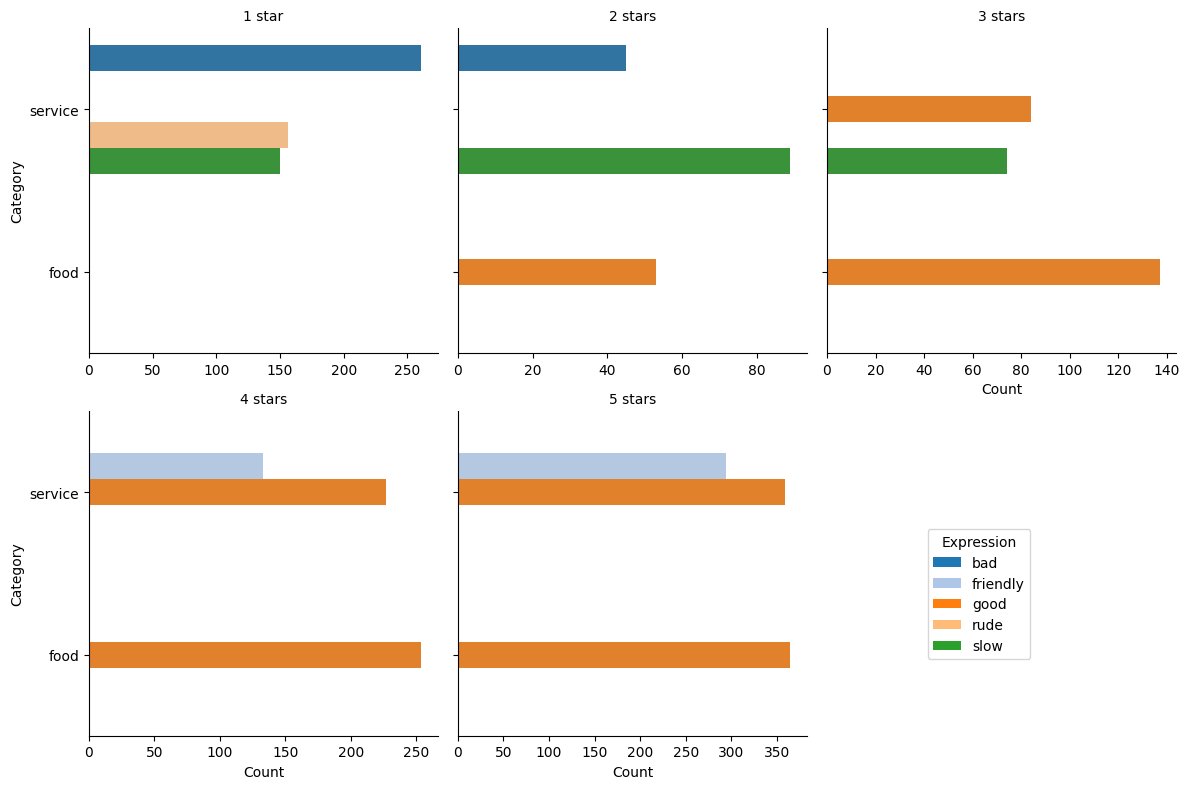

In [ ]:
# extract all expression value and sort
all_expressions = sorted(present_summary["expression"].unique())

# color palette adjusting
palette = sns.color_palette("tab20", len(all_expressions))

# mapping color palette with expression
color_mapping = dict(zip(all_expressions, palette))


# FacetGrid based on Rating
g = sns.FacetGrid(
    present_summary,
    col="rating",      
    col_wrap=3,        
    sharex=False,      
    height=4           
)

# bcreat bar plot
g.map_dataframe(
    sns.barplot,
    y="category",              
    x="count",                 
    hue="expression",          
    hue_order=all_expressions, 
    palette=color_mapping      
)


g.set_titles("{col_name}")
g.set_axis_labels("Count", "Category")

# delete default legend
if g._legend:
    g._legend.remove()


# create manual legend
legend_elements = [
    Patch(facecolor=color_mapping[exp], label=exp)
    for exp in all_expressions
]

g.fig.legend(
    handles=legend_elements,
    title="Expression",
    loc="center",
    bbox_to_anchor=(0.82, 0.25),
    frameon=True
)

plt.tight_layout()
plt.show()

According to the figure above, the research demonstrates that the food is never a negative experience for the customer. Neither with the service, which received some negative feedback owing to a horrible experience such as poor hospitality and delayed service. This implies that customers rarely received good service, and the food is reasonably priced.

## Text Exploratory

In [ ]:
#create new column for text length
df['review_len'] = df['clean_text'].fillna('').str.len()

In [83]:
# Summary statistics
stats = {
    'min_length': df['review_len'].min(),
    'max_length': df['review_len'].max(),
    'median_length': df['review_len'].median(),
    'mean_length': df['review_len'].mean()
}

stats

{'min_length': 0,
 'max_length': 3044,
 'median_length': 58.0,
 'mean_length': 115.66400167684753}

In [84]:
df['review_len'].describe()

count    33396.000000
mean       115.664002
std        170.367230
min          0.000000
25%         15.000000
50%         58.000000
75%        146.000000
max       3044.000000
Name: review_len, dtype: float64

According to the statistics described above, customers typically review approximately 58 words. This suggests that the review is straightforward and does not harshly condemn the eatery. 